In [1]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make the graphs look nicer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the three CSV files
sales = pd.read_csv("sales.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

print("Files loaded successfully!")

Files loaded successfully!


In [3]:
# Show the first 10 rows of each table
print("=== SALES (first 10 rows) ===")
display(sales.head(10))

print("\n=== FEATURES (first 10 rows) ===")
display(features.head(10))

print("\n=== STORES (first 10 rows) ===")
display(stores.head(10))

=== SALES (first 10 rows) ===


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False



=== FEATURES (first 10 rows) ===


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False



=== STORES (first 10 rows) ===


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [4]:
# Number of rows and columns
print("Sales shape (rows, columns):", sales.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

Sales shape (rows, columns): (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [5]:
# Data types of each column
print("=== Sales data types ===")
print(sales.dtypes)

print("\n=== Features data types ===")
print(features.dtypes)

print("\n=== Stores data types ===")
print(stores.dtypes)

=== Sales data types ===
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object

=== Features data types ===
Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

=== Stores data types ===
Store    int64
Type       str
Size     int64
dtype: object


In [6]:
# Key statistical measures
print("=== Sales statistics ===")
display(sales.describe())

print("\n=== Features statistics ===")
display(features.describe())

print("\n=== Stores statistics ===")
display(stores.describe())

=== Sales statistics ===


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000



=== Features statistics ===


,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000



=== Stores statistics ===


,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [7]:
# Convert Date columns from text to real dates
sales['Date'] = pd.to_datetime(sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print("Date conversion done!")
print("Sales Date type:", sales['Date'].dtype)
print("Features Date type:", features['Date'].dtype)

Date conversion done!
Sales Date type: datetime64[us]
Features Date type: datetime64[us]


In [8]:
# Convert IsHoliday to 0 and 1
sales['IsHoliday'] = sales['IsHoliday'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0})
features['IsHoliday'] = features['IsHoliday'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0})

print("IsHoliday conversion done!")
print(sales['IsHoliday'].value_counts())

IsHoliday conversion done!
IsHoliday
0    391909
1     29661
Name: count, dtype: int64


In [9]:
# Merge sales + features first
df = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Then add the store information
df = df.merge(stores, on='Store', how='left')

print("Merge completed!")
print("Final table shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Merge completed!
Final table shape (rows, columns): (421570, 16)

Column names:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


In [10]:
# Look at the first 10 rows of the big table
display(df.head(10))

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
5,1,1,2010-03-12,21043.39,0,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315
6,1,1,2010-03-19,22136.64,0,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,A,151315
7,1,1,2010-03-26,26229.21,0,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,A,151315
8,1,1,2010-04-02,57258.43,0,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,A,151315
9,1,1,2010-04-09,42960.91,0,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,A,151315


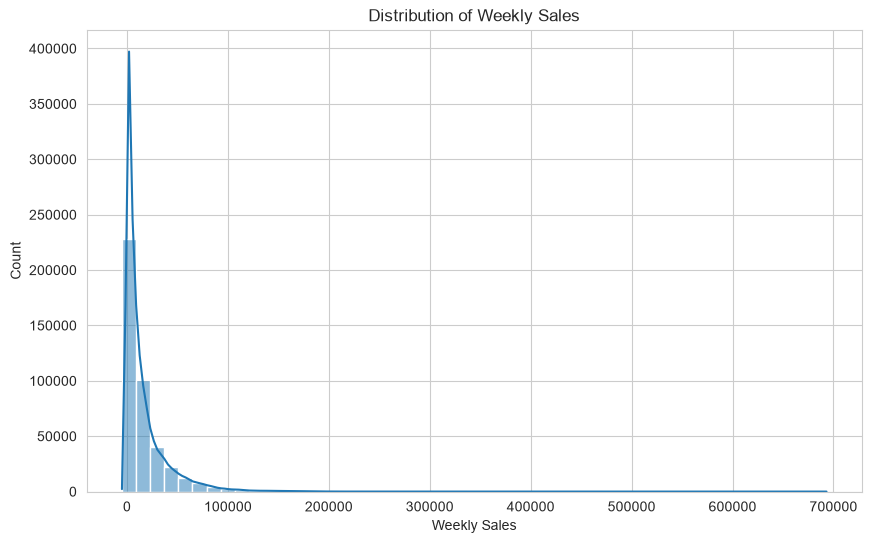

In [11]:
# Histogram of Weekly Sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Count')
plt.show()

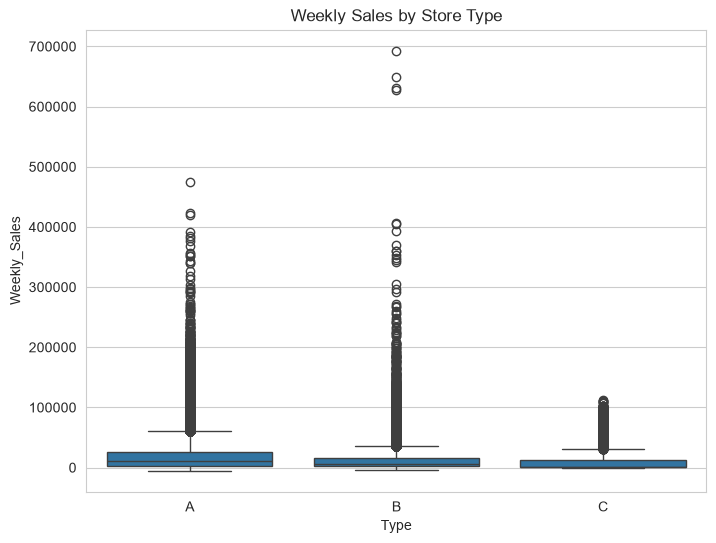

In [12]:
# Boxplot of Weekly Sales by Store Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.title('Weekly Sales by Store Type')
plt.show()

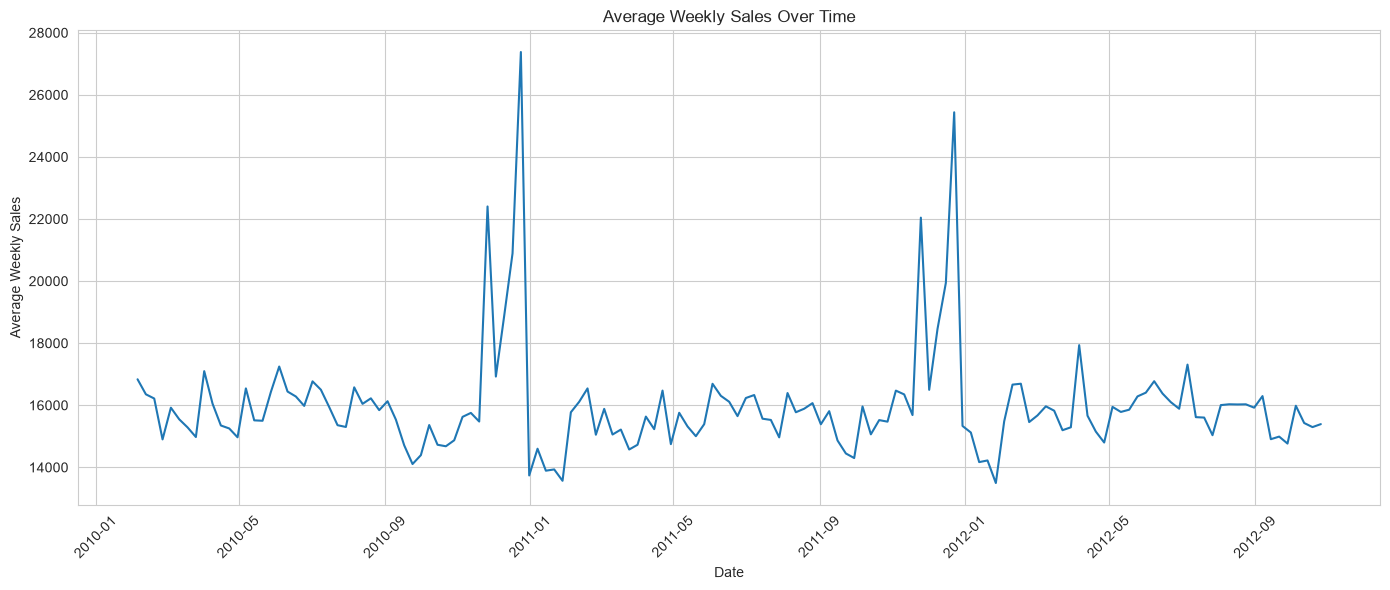

In [13]:
# Average Weekly Sales over time
avg_sales = df.groupby('Date')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(avg_sales['Date'], avg_sales['Weekly_Sales'])
plt.title('Average Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

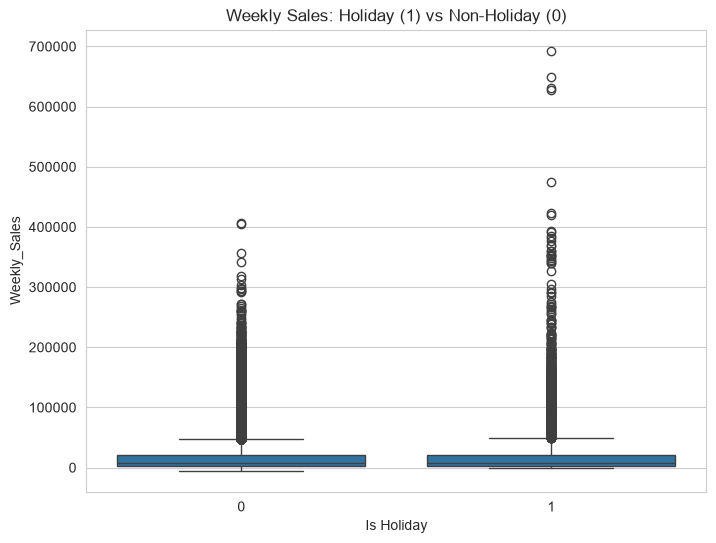

In [14]:
# Boxplot: Holiday vs Non-Holiday
plt.figure(figsize=(8, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Weekly Sales: Holiday (1) vs Non-Holiday (0)')
plt.xlabel('Is Holiday')
plt.show()

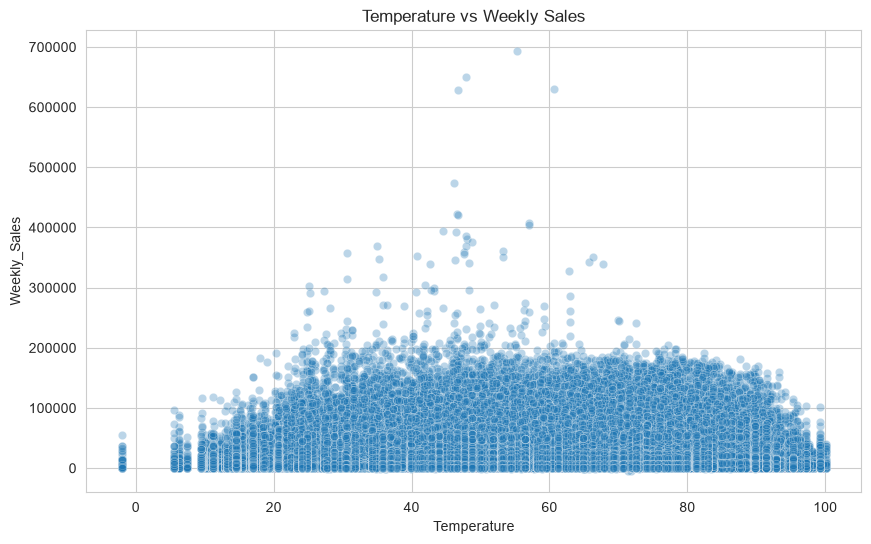

In [15]:
# Scatter plot: Temperature vs Weekly Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3)
plt.title('Temperature vs Weekly Sales')
plt.show()

In [16]:
# Check how many missing values each column has
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


In [17]:
# Fill missing MarkDown values with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

print("MarkDown missing values filled with 0")
print(df[markdown_cols].isnull().sum())

MarkDown missing values filled with 0
MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [18]:
# Check missing values after filling MarkDowns
print("Missing values after cleaning MarkDowns:")
print(df.isnull().sum())

Missing values after cleaning MarkDowns:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


In [21]:
# Fill remaining missing values using forward fill (new pandas style)
df['CPI'] = df['CPI'].ffill()
df['Unemployment'] = df['Unemployment'].ffill()

print("CPI and Unemployment filled (if any were missing)")
print(df.isnull().sum())

CPI and Unemployment filled (if any were missing)
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


In [22]:
# Convert Type (A, B, C) into numbers using one-hot encoding
df = pd.get_dummies(df, columns=['Type'], prefix='Type')

print("Type column converted to numbers")
print(df.head())

Type column converted to numbers
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50          0        42.31       2.572   
1      1     1 2010-02-12      46039.49          1        38.51       2.548   
2      1     1 2010-02-19      41595.55          0        39.93       2.514   
3      1     1 2010-02-26      19403.54          0        46.63       2.561   
4      1     1 2010-03-05      21827.90          0        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2        0.0        0.0        0.0        0.0        0.0  211.289143   
3        0.0        0.0        0.0        0.0        0.0  211.319643   
4        0.0        0.0        0.0        0.0        0.0  211.350143   

   Unemployment    Size  Type_A  Type_B  Type_C  
0        

In [23]:
# Final shape and missing values
print("Final shape of the table:", df.shape)
print("\nAny missing values left?")
print(df.isnull().sum().sum())   # should be 0

Final shape of the table: (421570, 18)

Any missing values left?
0


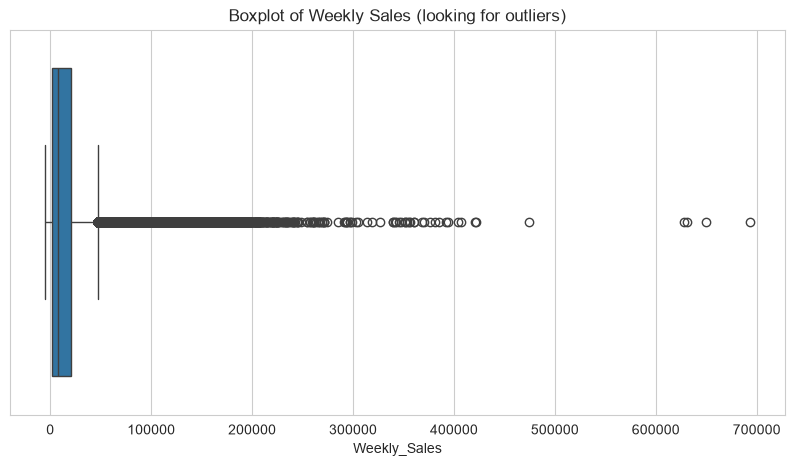

In [24]:
# Boxplot to see outliers in Weekly Sales
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Weekly_Sales'])
plt.title('Boxplot of Weekly Sales (looking for outliers)')
plt.show()

In [25]:
# Calculate IQR for Weekly_Sales
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Count how many outliers we have
outliers = df[(df['Weekly_Sales'] < lower_limit) | (df['Weekly_Sales'] > upper_limit)]
print("Number of outliers:", len(outliers))

Lower limit: -25109.653749999998
Upper limit: 47395.15625
Number of outliers: 35521


In [26]:
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Show the correlation with Weekly_Sales (most important)
print("Correlation with Weekly_Sales:")
print(corr_matrix['Weekly_Sales'].sort_values(ascending=False))

Correlation with Weekly_Sales:
Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
MarkDown2       0.020716
IsHoliday       0.012774
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64


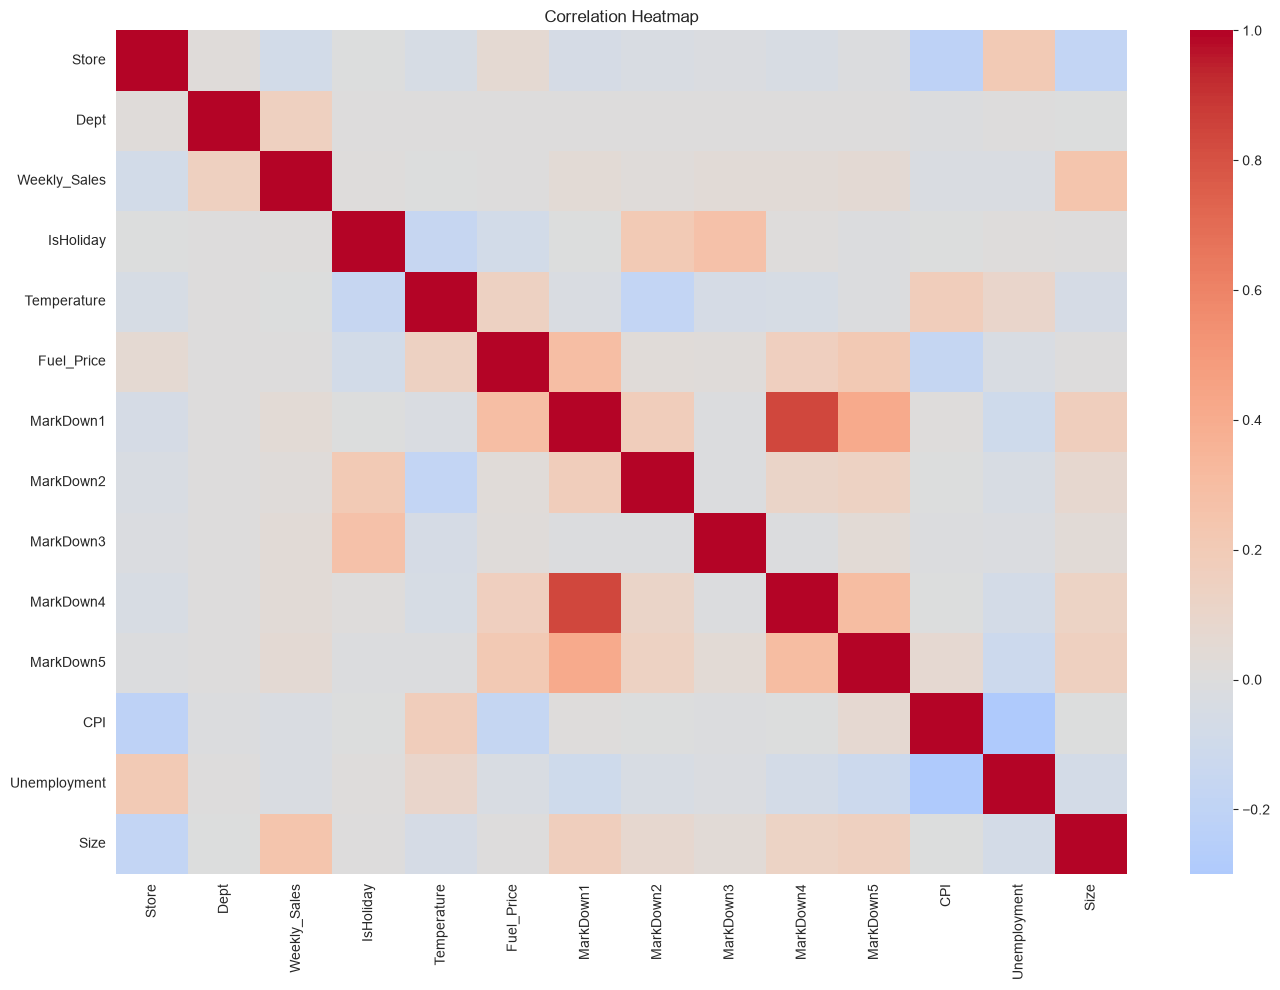

In [27]:
# Heatmap of correlations
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Summary

I chose the **W Store Sales** dataset because it is structured for weekly sales forecasting.

### What I did

1. **Loaded and explored the data**
   - Loaded `sales.csv`, `features.csv` and `stores.csv`.
   - Looked at the first 10 rows, data types, shape, and key statistics (mean, standard deviation, etc.).

2. **Prepared the data**
   - Converted the Date columns to proper datetime format.
   - Converted the IsHoliday column from True/False to 0 and 1.
   - Merged the three tables into one big table.

3. **Visualised the data**
   - Created histograms, boxplots, line charts and scatter plots.
   - Observed that sales are generally higher on holidays and that Store Type A tends to have higher sales.

4. **Cleaned the data**
   - Filled missing MarkDown values with 0 (they usually mean no promotion).
   - Used forward fill for any remaining missing CPI and Unemployment values.
   - Converted the Store Type (A/B/C) into numerical columns using one-hot encoding.
   - Checked for outliers in Weekly Sales using a boxplot and the IQR method. I decided to keep the high values because holiday spikes are real.

5. **Correlation analysis**
   - Calculated the correlation matrix and created a heatmap.
   - Found that Store Size and some other features have noticeable relationships with Weekly Sales.

### Final result
The dataset is now clean, fully numerical, and ready to be used for training a machine learning model in the next part of the project.